<a href="https://colab.research.google.com/github/khushi3117/Python-Projects/blob/main/DSE_SLR_Faculty_Notebook__28Week1t.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table align="left" width=100%>
    <tr>
        <td width="20%">
            <img src="faculty.png">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                  <b> Faculty Notebook <br> (Week 1) </b>
                </font>
            </div>
        </td>
        <td width="25%">
            <img src="GL-2.png">
        </td>
    </tr>
</table>

## Problem Statement

The New York City Controller's Office maintains a database of the salary and benefits paid to city employees since the fiscal year 2013. This is data representing the Employee Compensation report.

**Year Type:**		Fiscal (July through June) or Calendar (January through December)<br>

**Year:**		An accounting period of 12 months. The New York City operates operates on a fiscal year that begins on July 1 and ends on June 30 the following year. The Fiscal Year ending June 30, 2012 is represented as FY2011-2012.<br>

**Employee Identifier:**		Each distinct number in the “Employee Identifier” column represents one employee. These identifying numbers are not meaningful but rather are randomly assigned for the purpose of building this dataset.<br>

**Salaries:**		Normal salaries paid to permanent or temporary City employees. <br>

**Overtime:**		Amounts paid to City employees working in excess of 40 hours per week. <br>

**Other Salaries:**		Various irregular payments made to City employees including premium pay, incentive pay, or other one-time payments. <br>

**Total Salary:**		The sum of all salaries paid to City employees.<br>

**Retirement:**		City contributions to employee retirement plans. <br>

**Health/Dental:**		City-paid premiums to health and dental insurance plans covering City employees. To protect confidentiality as legally required, pro-rated citywide averages are presented in lieu of employee-specific health and dental benefits. <br>

**Other Benefits:**		Mandatory benefits paid on behalf of employees, such as Social Security (FICA and Medicare) contributions, unemployment insurance premiums, and minor discretionary benefits not included in the above categories.<br>

**Total Benefits:**		The sum of all benefits paid to City employees.<br>

**Total Compensation:**		The sum of all salaries and benefits paid to City employees.

## Table of Content

1. **[Import Libraries](#lib)**
2. **[Data Preparation](#prep)**
    - 2.1 - **[Understand the Data](#read)**
    - 2.2 - **[Outlier Analysis and Treatment](#outlier)**
    - 2.3 - **[Missing Value Analysis and Treatment](#null)**
    - 2.4 - **[Scale the Data](#scale)**
3. **[What is Regression Analysis?](#def)**

4. **[Multiple Linear Regression (MLR)](#MLR)**
    - 4.1 - **[Assumptions Before MLR Model](#before)**
        - 4.1.1 - **[Assumption on Dependent Variable](#dep_num)**
        - 4.1.2 - **[No or Little Multicollinearity](#no_multi)**
          - 4.1.2.1 - **[Correlation Matrix](#corr)**
          - 4.1.2.2 - **[Variance Inflation Factor (VIF)](#vif)**
    - 4.2 - **[Build the MLR Model](#model)**
       - 4.2.1 - **[MLR Full Model](#full)**
       - 4.2.2 - **[MLR Model after Removing Insignificant Variables](#signi_var)**
       - 4.2.3 - **[MLR Model with Interaction Effect](#interaction)**
    - 4.3 - **[Assumptions After MLR Model](#assum)**
        - 4.3.1 - **[Linear Relationship between Dependent and Independent Variable](#linear_reln)**
        - 4.3.2 - **[Autocorrelation](#auto)**
        - 4.3.3 - **[Heteroskedasticity](#sked)**
        - 4.3.4 - **[Tests for Normality](#normality)**
5. **[Model Evaluation](#eval)**
    - 5.1 - **[R-Squared](#R_squared)**
    - 5.2 - **[Adjusted R-Squared](#Adj_R_test)**
    - 5.3 - **[Overall F-Test & p-value of the Model](#overall)**
6. **[Model Performance](#ml_perf)**
    - 6.1 - **[Mean Squared Error (MSE)](#mse)**
    - 6.2 - **[Root Mean Squared Error (RMSE)](#rmse)**
    - 6.3 - **[Mean Absolute Error (MAE)](#mae)**
    - 6.4 - **[Mean Absolute Percentage Error (MAPE)](#mape)**
7. **[Compare Model Performances](#compare)**

<a id="lib"></a>
# 1. Import Libraries

**Let us import the required libraries.**

In [ ]:
# import 'Pandas'
import pandas as pd

# import 'Numpy'
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn'
import seaborn as sns

# to suppress warnings
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None

# to display the float values upto 6 decimal places
pd.options.display.float_format = '{:.6f}'.format

# import train-test split
from sklearn.model_selection import train_test_split

# import various functions from statsmodel to perform linear regression
import statsmodels
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
from statsmodels.tools.eval_measures import rmse

# import various functions from scipy
from scipy import stats
from scipy.stats import shapiro

# 'metrics' from sklearn is used for evaluating the model performance
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 10,6

In [ ]:
from IPython.display import Image

<a id="prep"></a>
# 2. Data Preparation

<a id="read"></a>
## 2.1 Understand the Data

#### Read the dataset and print the first five observations.

In [ ]:

df_compensation = pd.read_csv('employee_compensation.csv')

df_compensation.head()

,Year_Type,Year,Employee_Identifier,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Total_Compensation
0,Fiscal,2015,42853,92288.220000,267.450000,267.450000,92823.120000,20700.200000,12500.560000,7605.750000,40806.510000,133629.630000
1,Calendar,2015,28248,1466.380000,348.230000,0.000000,1814.610000,0.000000,442.030000,141.590000,583.620000,2398.230000
2,Fiscal,2014,30651,76536.950000,13583.720000,10855.940000,100976.610000,18632.190000,12464.610000,8011.410000,39108.210000,140084.820000
3,Fiscal,2014,19473,45659.880000,0.000000,1625.370000,47285.250000,10081.200000,0.000000,3936.630000,14017.830000,61303.080000
4,Fiscal,2013,7176,41832.000000,0.000000,0.000000,41832.000000,7617.600000,5908.520000,3254.500000,16780.620000,58612.620000


**Let us now see the number of variables and observations in the data.**

In [ ]:
df_compensation.shape

(50000, 12)

**Interpretation:** The data has 50000 observations and 12 variables.

**Get a concise summary of the DataFrame.**

In [ ]:
df_compensation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Type            50000 non-null  object 
 1   Year                 50000 non-null  int64  
 2   Employee_Identifier  50000 non-null  int64  
 3   Salaries             50000 non-null  float64
 4   Overtime             50000 non-null  float64
 5   Other_Salaries       50000 non-null  float64
 6   Total_Salary         50000 non-null  float64
 7   Retirement           50000 non-null  float64
 8   Health/Dental        50000 non-null  float64
 9   Other_Benefits       50000 non-null  float64
 10  Total_Benefits       50000 non-null  float64
 11  Total_Compensation   50000 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 4.6+ MB


**Interpretation:** The variable `Year_Type` is categorical. All the other variables are numerical.

From the above output, we see that the data type of `Year` is 'int64'.

But according to the data definition, `Year` is categorical variable, which is wrongly interpreted as 'int64', so we will convert these variables data type to 'object'.

#### Change the data type as per the data definition.

In [ ]:
df_compensation['Year'] = df_compensation['Year'].astype(object)

#### Recheck the data type after the conversion.

In [ ]:
df_compensation.dtypes

Year_Type               object
Year                    object
Employee_Identifier      int64
Salaries               float64
Overtime               float64
Other_Salaries         float64
Total_Salary           float64
Retirement             float64
Health/Dental          float64
Other_Benefits         float64
Total_Benefits         float64
Total_Compensation     float64
dtype: object

**Interpretation:** Now, all the variables have the correct data type.

<a id="drop"></a>
## 2.3 Remove Insignificant Variables

The column `Employee_Identifier` contains the id of the employee, which is redundant for further analysis. Thus, we drop the column.

In [ ]:
df_compensation = df_compensation.drop('Employee_Identifier',axis=1)

<a id="outlier"></a>
## 2.2 Outlier Analysis and Treatment

**Check the outliers in all the variables and treat them using appropriate techniques.**

<AxesSubplot:>

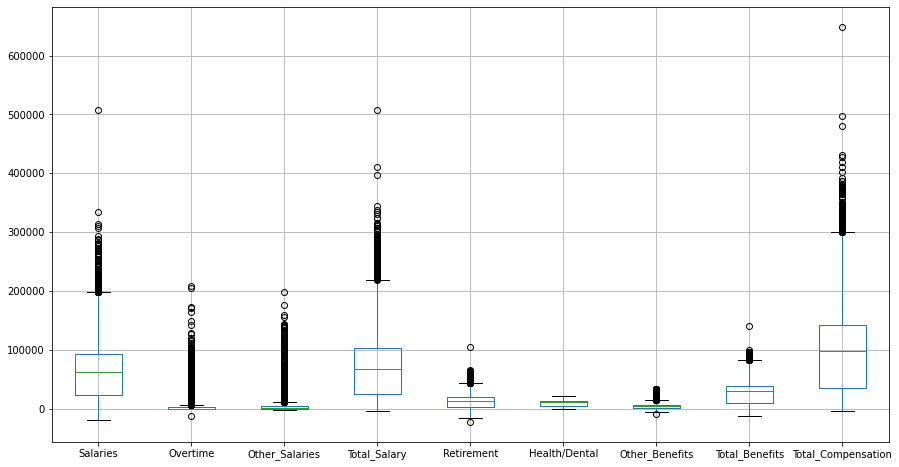

In [ ]:
plt.figure(figsize = (15,8))

df_compensation.boxplot()



**Notice that the variables 'Salaries', 'Total_Salary' and 'Total_Compensation' have a quite large range as compared to the other variables. Thus, it is difficult to see the outliers in such variables. So, we plot the boxplots of independent variables again by not considering the variables 'Salaries', 'Total_Salary' and 'Total_Compensation'. The variable Health/Dental has no outliers.**

In [ ]:
q1 =df_compensation.quantile(0.25)
q3= df_compensation.quantile(0.75)
iqr=q3-q1

upper_limit= q3+1.5*iqr
lower_limit= q1-1.5*iqr

1. '~' returns the values that do not satisfy the given conditions
i.e. it returns values between the range [Q1-1.5*IQR, Q3+1.5*IQR]
2. '|' is used as 'OR' operator on multiple conditions   
3. 'any(axis=1)' checks the entire row for atleast one 'True' entry (those rows represents outliers in the data)

1. Return the output row by row. Instead of Column by column.
2. Check rowwise, if the condition is met and return that data. In the second row, where the condition is met, retun the data. If the condition is not met then do not return the data.
3. any means- if the condition is met anywhere, return this data.
4. ~: Not represents returning all the values which are false.
5. ex: not(false) = True. , Not(True) = False.
6. .any(axis=1) : represents checking of the condition row wise. And whenever this condition is met, it returns the data.
7. Return the data which is the layer.

In [ ]:
#~(df_compensation > upper_limit ) | (df_compensation < lower_limit).any(axis=1)
df_compensation = df_compensation[~((df_compensation < (lower_limit)) | (df_compensation > (upper_limit))).any(axis=1)]
df_compensation.head()

,Year_Type,Year,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Total_Compensation
0,Fiscal,2015,92288.220000,267.450000,267.450000,92823.120000,20700.200000,12500.560000,7605.750000,40806.510000,133629.630000
1,Calendar,2015,1466.380000,348.230000,0.000000,1814.610000,0.000000,442.030000,141.590000,583.620000,2398.230000
3,Fiscal,2014,45659.880000,0.000000,1625.370000,47285.250000,10081.200000,0.000000,3936.630000,14017.830000,61303.080000
4,Fiscal,2013,41832.000000,0.000000,0.000000,41832.000000,7617.600000,5908.520000,3254.500000,16780.620000,58612.620000
5,Calendar,2013,74132.000000,0.000000,1443.420000,75575.420000,14851.230000,12888.340000,6233.850000,33973.420000,109548.840000


In [ ]:
df_compensation.shape

(37721, 11)

<a id="null"></a>
## 2.3 Missing Value Analysis and Treatment

**Check the presence of missing values in the data and treat them.**

In [ ]:
df_compensation.isnull().sum()

Year_Type             0
Year                  0
Salaries              0
Overtime              0
Other_Salaries        0
Total_Salary          0
Retirement            0
Health/Dental         0
Other_Benefits        0
Total_Benefits        0
Total_Compensation    0
dtype: int64

In [ ]:
# to know the percent of missing values
(df_compensation.isnull().sum() /df_compensation.index.size) *100

Year_Type            0.000000
Year                 0.000000
Salaries             0.000000
Overtime             0.000000
Other_Salaries       0.000000
Total_Salary         0.000000
Retirement           0.000000
Health/Dental        0.000000
Other_Benefits       0.000000
Total_Benefits       0.000000
Total_Compensation   0.000000
dtype: float64

**Interpretation:** There are no missing values in the data.

<a id="scale"></a>
## 2.4 Scale the Data

In [ ]:
df_compensation.head()

,Year_Type,Year,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Total_Compensation
0,Fiscal,2015,92288.220000,267.450000,267.450000,92823.120000,20700.200000,12500.560000,7605.750000,40806.510000,133629.630000
1,Calendar,2015,1466.380000,348.230000,0.000000,1814.610000,0.000000,442.030000,141.590000,583.620000,2398.230000
3,Fiscal,2014,45659.880000,0.000000,1625.370000,47285.250000,10081.200000,0.000000,3936.630000,14017.830000,61303.080000
4,Fiscal,2013,41832.000000,0.000000,0.000000,41832.000000,7617.600000,5908.520000,3254.500000,16780.620000,58612.620000
5,Calendar,2013,74132.000000,0.000000,1443.420000,75575.420000,14851.230000,12888.340000,6233.850000,33973.420000,109548.840000


In [ ]:
# scale the independent numeric variables
df_compensation.iloc[:, 2:11] = df_compensation.iloc[:, 2:11].apply(lambda rec: (rec - rec.mean()) / rec.std())

df_compensation.head()

,Year_Type,Year,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Total_Compensation
0,Fiscal,2015,0.983488,-0.228091,-0.474919,0.926912,1.178494,0.916565,1.145315,1.160922,1.001727
1,Calendar,2015,-1.252266,-0.167552,-0.587276,-1.263215,-1.180529,-1.491462,-1.259970,-1.365191,-1.304472
3,Fiscal,2014,-0.164358,-0.428525,0.095551,-0.168961,-0.031662,-1.579733,-0.037039,-0.521484,-0.269306
4,Fiscal,2013,-0.258589,-0.428525,-0.587276,-0.300194,-0.312417,-0.399832,-0.256852,-0.347973,-0.316586
5,Calendar,2013,0.536538,-0.428525,0.019113,0.511845,0.511937,0.994002,0.703228,0.731784,0.578543


<a id="def"></a>
# 3. What is Regression Analysis?

#### Dependent variable (y): It is the variable that we predict. It is also known as 'Target' or 'Response' variable. For regression, the dependent variable should be numeric.

#### Independent variable (X): It is the variable used in predicting the values of a target variable. There can be one or more independent variables in a dataset. It is also known as 'predictors' or 'features'. These variables can be numerical as well as categorical.

Regression analysis is used to understand the effect of a set of independent variables on the dependent variable. The variables that affect the dependent variable the most can also be identified. Linear regression is one of the methods in regression analysis, which fits the line to predict the values of the dependent variable.

<a id="Bivariate"></a>
# 4. Bivariate Regression

It determines the linear relationship between the dependent (y) and a independent (X) variable. It is also known as, `Simple Linear Regression (SLR)`. The mathematical equation is given as:<br>
<p style='text-indent:30em'> <strong> y = β<sub>0</sub> + β<sub>1</sub>.x + ε </strong> </p>
                                                        
where,

y   =  Dependent variable <br>
x   =  Independent variable<br>
β<sub>0</sub>  =  Y-intercept (value of y when x = 0)<br>
β<sub>1</sub>  =  Beta coefficient of x <br>
ε   =  Random error component<br>

**For bivariate regression, consider 'Total_Compensation' as target variable and 'Total_Benefits' as an independent variable from 'df_compensation'.**

The test hypothesis for SLR is given as:
<p style='text-indent:25em'> <strong> H<sub>o</sub>: Slope (beta coefficient of x) is equal to zero</strong> </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>: Slope (beta coefficient of x) is not equal to zero</strong> </p>

<a id="lsm"></a>
## 4.1 Ordinary Least Square Method (OLS)

The ordinary least square method aims to minimize the sum of the squared difference between the actual and the predicted values. Squaring ensures that each term is positive. It penalizes the model for the negative error terms. This approach calculates the β<sub>0</sub> and β<sub>1</sub> values that minimize the sum of squared differences along the line of prediction.

<a id="MLR"></a>
# 5. Multiple Linear Regression (MLR)

It is used to study the linear relationship between a dependent (target) variable and two or more independent variables. We can use this technique to study the effect of multiple variables on the target variable.

<a id="before"></a>
## 5.1 Assumptions Before MLR Model

There are several assumptions of linear regression. We can check two of them before building the regression model. Let us check the following assumptions in this section:<br>
1. Assumption on Dependent Variable<br>
2. No or little multicollinearity<br>

Let us create the dataframes for independent and target variable to check the assumptions of linear regression.

In [ ]:

df_feature = df_compensation.drop('Total_Compensation', axis = 1)

df_target = df_compensation['Total_Compensation']

<a id="dep_num"></a>
### 5.1.1 Assumption on Dependent Variable

The assumption for linear regression is that the dependent (target) variable should be numeric. In our dataset, the variable 'Total_Compensation' is the target/dependent variable.  

In [ ]:
# check the data type of dependent variable
df_target.dtype

dtype('float64')

**Interpretation:** The output shows that the data type of target variable is 'float64'. i.e. the dependent variable is numeric.

<a id="no_multi"></a>
### 5.1.2 No or Little Multicollinearity

Whenever there are a large number of independent variables present in the dataset, there is a possibility that such independent variables will be strongly correlated. The presence of a strong correlation between the independent variables is called multicollinearity.

The presence of multicollinearity can destabilize the model. Thus, the existence of multicollinearity must be detected and corrected actions should be taken.

If we use dummy variables to encode a categorical variable and do not omit the parent column, then this results in a strong correlation between the dummy variables and the parent column.

<a id="corr"></a>
#### 5.1.2.1 Correlation Matrix

Let us plot the heatmap to visualize the correlation matrix of the independent variables. The variables with a high correlation may induce multicollinearity in the data.

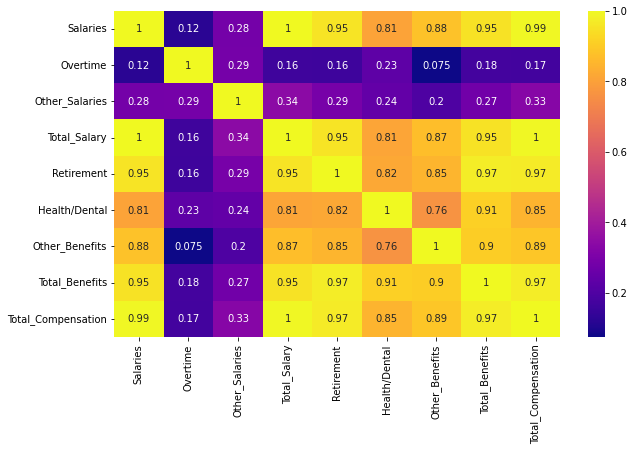

In [ ]:
sns.heatmap(df_compensation.corr(),annot=True,cmap="plasma")
plt.show()

Identify the variables with a correlation greater than 0.6 and less than -0.6.

<a id="vif"></a>
#### 5.1.2.2 Variance Inflation Factor (VIF)

The Variance Inflation Factor (VIF) is used to detect the presence of multicollinearity between the features. The value of VIF equal to 1 indicates that no features are correlated. We calculate VIF of the numerical independent variables.   

Steps to calculate VIF:<br>
1. Regress one independent variable (say V<sub>i</sub>) on all the remaining independent variables (say V<sub>j</sub>, j ≠ i)
2. Calculate R-squared of the regression model
3. Calculate VIF for the variable V<sub>i</sub> using the formula:
<p style='text-indent:29em'> <strong> VIF = 1 / (1 - R-squared)</strong>  </p><br>
4. Repeate the steps 1 to 3 to calculate VIF of each independent variable

In [ ]:
df_vif = df_feature.select_dtypes(include=[np.number])


df_vif.head()

,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits
0,0.983488,-0.228091,-0.474919,0.926912,1.178494,0.916565,1.145315,1.160922
1,-1.252266,-0.167552,-0.587276,-1.263215,-1.180529,-1.491462,-1.259970,-1.365191
3,-0.164358,-0.428525,0.095551,-0.168961,-0.031662,-1.579733,-0.037039,-0.521484
4,-0.258589,-0.428525,-0.587276,-0.300194,-0.312417,-0.399832,-0.256852,-0.347973
5,0.536538,-0.428525,0.019113,0.511845,0.511937,0.994002,0.703228,0.731784


#### Calculate the VIF for each numeric variable.

Working of VIF
------------------------
	1. It never includes your target. Because, we want all the predictors to have good relationship with the target. We are only referring to X and not Y.
	2. Each variable will be considered as Target with the rest of the predictors as independent variables.
	3. This keeps happening till all the features are exhausted.
	4. R2 is calculated for each of the variable. This R2 is not of the Model.
	5. Value is replaced in VIF formula and calculated.
	6. VIF is calculated in the form of the table.
	7. VIF > 10 is considered to be highly correlated. Between 1-5 hardly collinear.
	8. Consider only the training data- xtrain and not target -y.


Difference Between Condition No: and VIF
-----------------------------------------------------------
	1. VIF tells which features are highly correlated vs the rest.  Condition No: Will tell about the whole model. VIF will tell about each and every column.
	2. VIF tells about each and every feature.  VIF = 1/1-R2

# Variation Inflation Factor

The Variance Inflation Factor (VIF) is used to detect the presence of multicollinearity between the features. The value of VIF equal to 1 indicates that no features are correlated. We calculate VIF of the numerical independent variables.

Steps to calculate VIF:

1. Regress one independent variable on all the remaining independent variables
2. Calculate R-squared of the regression model
3. Calculate VIF for the variable Vi using the formula:

VIF = 1 / (1 - R-squared)


Repeate the steps 1 to 3 to calculate VIF of each independent variable

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df_vif.head()

,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits
0,0.983488,-0.228091,-0.474919,0.926912,1.178494,0.916565,1.145315,1.160922
1,-1.252266,-0.167552,-0.587276,-1.263215,-1.180529,-1.491462,-1.259970,-1.365191
3,-0.164358,-0.428525,0.095551,-0.168961,-0.031662,-1.579733,-0.037039,-0.521484
4,-0.258589,-0.428525,-0.587276,-0.300194,-0.312417,-0.399832,-0.256852,-0.347973
5,0.536538,-0.428525,0.019113,0.511845,0.511937,0.994002,0.703228,0.731784


In [ ]:
# for i in range(df_numeric_features_vif.shape[1]): # 1 is for columns
#   print(i)

In [ ]:
# for each numeric variable, calculate VIF and save it in a dataframe 'vif'


for ind in range(len(df_vif.columns)):

    # create an empty dataframe
    vif = pd.DataFrame()

    # calculate VIF using list comprehension
    # use for loop to access each variable
    # calculate VIF for each variable and create a column 'VIF_Factor' to store the values
    vif["VIF_Factor"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

    # create a column of variable names
    vif["Features"] = df_vif.columns

    # filter the variables with VIF greater than 10 and store it in a dataframe 'multi'
    # one can choose the threshold other than 10 (it depends on the business requirements)


    multi = vif[vif['VIF_Factor'] > 10]

    # if dataframe 'multi' is not empty, then sort the dataframe by VIF values
    # if dataframe 'multi' is empty (i.e. all VIF <= 10), then print the dataframe 'vif' and break the for loop using 'break'
    # 'by' sorts the data using given variable(s)
    # 'ascending = False' sorts the data in descending order



    if(multi.empty == False):
        df_sorted = multi.sort_values(by = 'VIF_Factor', ascending = False)
    else:
        print(vif)
        break

    # use if-else to drop the variable with the highest VIF
    # if  dataframe 'df_sorted' is not empty, then drop the first entry in the column 'Features' from the numeric variables
    # select the variable using 'iloc[]'
    # 'axis=1' drops the corresponding column
    #  else print the final dataframe 'vif' with all values after removal of variables with VIF less than 10


    if (df_sorted.empty == False):
        df_vif = df_vif.drop(df_sorted.Features.iloc[0], axis=1)
    else:
        print(vif)

   VIF_Factor        Features
0    1.158679        Overtime
1    1.257229  Other_Salaries
2    5.848646    Total_Salary
3    3.177166   Health/Dental
4    4.635685  Other_Benefits


In [ ]:
# display the first 5 observations
df_vif.head()

,Overtime,Other_Salaries,Total_Salary,Health/Dental,Other_Benefits
0,-0.228091,-0.474919,0.926912,0.916565,1.145315
1,-0.167552,-0.587276,-1.263215,-1.491462,-1.259970
3,-0.428525,0.095551,-0.168961,-1.579733,-0.037039
4,-0.428525,-0.587276,-0.300194,-0.399832,-0.256852
5,-0.428525,0.019113,0.511845,0.994002,0.703228


**Interpretation** Now, we have all the variables with VIF less than 10. So, we can conclude that there is no multicollinearity in the data.<br>
We will use the above dataframe "df_numeric_features_vif" to build the MLR model with significant variables.

<a id="model"></a>
## 5.2 Build the MLR Model

<a id="full"></a>
### 5.2.1 MLR Full Model

We use the OLS technique to predict the Total_Compensation by considering all the independent features in the data.

#### Filter numerical and categorical variables

In [ ]:

df_feature = df_compensation.drop('Total_Compensation', axis = 1)


df_target = df_compensation['Total_Compensation']

In [ ]:

df_num = df_feature.select_dtypes(include=[np.number])

# display numerical features
df_num.columns

Index(['Salaries', 'Overtime', 'Other_Salaries', 'Total_Salary', 'Retirement',
       'Health/Dental', 'Other_Benefits', 'Total_Benefits'],
      dtype='object')

In [ ]:

df_cat = df_feature.select_dtypes(include=[np.object])

# display categorical features
df_cat.columns

Index(['Year_Type', 'Year'], dtype='object')

The OLS method fails in the presence of categorical variables. To overcome this we use (n-1) dummy encoding.

**Encode the categorical variable 'medincome' and create (n-1) dummy variables for n categories of 'medincome'.**

In [ ]:

encoded_data = pd.get_dummies(data = df_cat, drop_first=True)

In [ ]:
encoded_data.head()

,Year_Type_Fiscal,Year_2014,Year_2015,Year_2016
0,1,0,1,0
1,0,0,1,0
3,1,1,0,0
4,1,0,0,0
5,0,0,0,0


#### Concatenate numerical and dummy encoded categorical variables.

In [ ]:

df_compensation_dummy = pd.concat([df_compensation, encoded_data], axis=1)

# display first five observations
df_compensation_dummy.head()

,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Year_Type_Fiscal,Year_2014,Year_2015,Year_2016
0,0.983488,-0.228091,-0.474919,0.926912,1.178494,0.916565,1.145315,1.160922,1,0,1,0
1,-1.252266,-0.167552,-0.587276,-1.263215,-1.180529,-1.491462,-1.259970,-1.365191,0,0,1,0
3,-0.164358,-0.428525,0.095551,-0.168961,-0.031662,-1.579733,-0.037039,-0.521484,1,1,0,0
4,-0.258589,-0.428525,-0.587276,-0.300194,-0.312417,-0.399832,-0.256852,-0.347973,1,0,0,0
5,0.536538,-0.428525,0.019113,0.511845,0.511937,0.994002,0.703228,0.731784,0,0,0,0


**Interpretation:** We can see that the dummy variables are added to the data.

#### Split the data into training and test sets.

In [ ]:
# set of independent variables
# create a copy of 'df_compensation_dummy' and store in the dataframe 'X_full'

X= df_compensation_dummy.copy()

# dependent variable
# create a copy of 'df_target' and store in the dataframe 'y_full'
y = df_target.copy()

# to estimate the regression coefficient, a constant term of '1' needs to be added as a separate column
# 'sm.add_constant' adds the intercept to the model

import statsmodels.api as sm
X= sm.add_constant(X)

# split data into train subset and test subset
# set 'random_state' to generate the same dataset each time you run the code
# 'test_size' returns the proportion of data to be included in the testing set


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=1,
                                                    test_size = 0.3)



**Build the multiple linear regression model using the OLS method.**

## Develop model with all the features - Full model

In [ ]:
# build a model on training dataset
# fit() is used to fit the OLS model
MLR_full_model = sm.OLS(y_train, X_train).fit()

# print the summary output
print(MLR_full_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.744e+33
Date:                Sat, 04 Mar 2023   Prob (F-statistic):               0.00
Time:                        14:30:01   Log-Likelihood:             8.6914e+05
No. Observations:               26404   AIC:                        -1.738e+06
Df Residuals:                   26393   BIC:                        -1.738e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -6.124e-16   1.67e-17  

**Interpretation:** The R-squared value obtained from this model is 1.0 which means that the above model explains a 100% of the variation in the Total_Compensation. But, this can't be possible.<br>

The `Durbin-Watson` test is used to check the autocorrelation between the residuals.

If the Durbin-Watson test statistic is near to 2: no autocorrelation<br>
If the Durbin-Watson test statistic is between 0 and 2: positive autocorrelation <br>
If the Durbin-Watson test statistic is between 2 and 4: negative autocorrelation

The summary output shows that the value of the test statistic is far from 2 (= 2.0008) which means there is autocorrelation.

The `Jarque-Bera` test is used to check the normality of the residuals. Here, the p-value of the test is less than 0.05; that implies the residuals are not normally distributed.

Also, the 'Cond. No' (1.94e+16) represents the `Condition Number (CN)` that is used to check the multicollinearity.

If CN < 100: no multicollinearity.<br>
If CN is between 100 and 1000: moderate multicollinearity<br>
If CN > 1000: severe multicollinearity

Thus, it can be seen that there is severe multicollinearity in the data.

#### Predict the Total_Compensation using X_test

In [ ]:
y_pred= MLR_full_model.predict(X_test)

<a id="signi_var"></a>
### 5.2.2 MLR Model after Removing Insignificant Variables

Now, let us build the model using the categorical variable and the variables obtained from VIF.

#### Filter numerical and categorical variables

In [ ]:
# display numeric features obtained from VIF
df_vif.columns

Index(['Overtime', 'Other_Salaries', 'Total_Salary', 'Health/Dental',
       'Other_Benefits'],
      dtype='object')

In [ ]:
# filter the categorical features in the dataset
# 'select_dtypes' is used to select the variables with given data type
# 'include=[np.object]' will include all the categorical variables


df_cat = df_feature.select_dtypes(include=[np.object])

# display categorical features
df_cat.columns

Index(['Year_Type', 'Year'], dtype='object')

The OLS method fails in the presence of categorical variables. To overcome this we use (n-1) dummy encoding.

**Encode the categorical variables and create (n-1) dummy variables for n categories.**

In [ ]:
# use 'get_dummies' from pandas to create dummy variables
# use 'drop_first' to create (n-1) dummy variables

encoded_data = pd.get_dummies(data = df_cat, drop_first=True)

#### Concatenate numerical and dummy encoded categorical variables.

## Develop models with features with no or very less multicollinearity

In [ ]:
# concat the dummy variables with numeric features to create a dataframe of all independent variables
# 'axis=1' concats the dataframes along columns

# earlier we had build the model using all the feature
# df_compensation_dummy = pd.concat([df_num, encoded_data], axis=1)

# Now we are building the model with features with No multicollinearity
df_compensation_dummy = pd.concat([df_vif, encoded_data], axis=1)

# display first five observations
df_compensation_dummy.head()

,Overtime,Other_Salaries,Total_Salary,Health/Dental,Other_Benefits,Year_Type_Fiscal,Year_2014,Year_2015,Year_2016
0,-0.228091,-0.474919,0.926912,0.916565,1.145315,1,0,1,0
1,-0.167552,-0.587276,-1.263215,-1.491462,-1.259970,0,0,1,0
3,-0.428525,0.095551,-0.168961,-1.579733,-0.037039,1,1,0,0
4,-0.428525,-0.587276,-0.300194,-0.399832,-0.256852,1,0,0,0
5,-0.428525,0.019113,0.511845,0.994002,0.703228,0,0,0,0


**Interpretation:** We can see that the dummy variables are added to the data.

#### Split the data into training and test sets.

In [ ]:
# set of independent variables
# create a copy of 'df_compensation_dummy' and store in the dataframe 'X'
X= df_compensation_dummy.copy()

# dependent variable
# create a copy of 'df_target' and store in the dataframe 'y'

y = df_target.copy()

# to estimate the regression coefficient, a constant term of '1' needs to be added as a separate column
# 'sm.add_constant' adds the intercept to the model

import statsmodels.api as sm
X = sm.add_constant(X)

# split data into train subset and test subset
# set 'random_state' to generate the same dataset each time you run the code
# 'test_size' returns the proportion of data to be included in the testing set


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=1,
                                                    test_size = 0.3)




**Build the multiple linear regression model using the OLS method.**

In [ ]:
# build a model on training dataset
# fit() is used to fit the OLS model

#               sm.OLS(y ,x).fit()
MLR_model_vif = sm.OLS(y_train, X_train).fit()

# print the summary output
print(MLR_model_vif.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.567e+06
Date:                Sat, 04 Mar 2023   Prob (F-statistic):               0.00
Time:                        14:30:01   Log-Likelihood:                 45594.
No. Observations:               26404   AIC:                        -9.117e+04
Df Residuals:                   26394   BIC:                        -9.109e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0124      0.001  

**Interpretation:** The R-squared value obtained from this model is 0.998 which means that the above model explains a 98.8% of the variation in the Total_Compensation. Also, we can see that the p-value for some variabels is greater than 0.05, we remove such variables and agan build the model.

Now, calculate the p-values for each variable and create a list of all insignificant variables in the model.

#### Calculate the p-values to know the insignificant variables

In [ ]:
# calculate p-values for all the independent variables in the MLR_model
# create a dataframe containing p-values
# pass the column name to the parameter 'columns'



MLR_pvalues = pd.DataFrame(MLR_model_vif.pvalues, columns = ["P-Value"])

# print the dataframe
MLR_pvalues

,P-Value
const,0.000000
Overtime,0.909313
Other_Salaries,0.000000
Total_Salary,0.000000
Health/Dental,0.000000
Other_Benefits,0.000000
Year_Type_Fiscal,0.201549
Year_2014,0.000000
Year_2015,0.000000
Year_2016,0.000000


**Interpretation:** The above table shows the p-value of each variable. Use this dataframe to identify the significant variables.

#### Create a list of insignificant variables.

In [ ]:
MLR_pvalues[1:][MLR_pvalues[1:]['P-Value'] > 0.05]

,P-Value
Overtime,0.909313
Year_Type_Fiscal,0.201549


In [ ]:
insigni_var = ['Overtime', 'Year_Type_Fiscal']

In [ ]:
# # subset the dataframe 'MLR_pvalues' such that the variables will have p-value greater than 0.05
# # store the subset of a dataframe to a new dataframe 'insignificant_var'



# insignificant_var = MLR_pvalues[1:][MLR_pvalues[1:]['P-Value'] > 0.05]

# # get the variable names with p-value greater than 0.05
# insigni_var = insignificant_var.index

# # convert the variables to the type 'list' using 'to_list()'
# insigni_var = insigni_var.to_list()

# # print the list of insignificant variables
# insigni_var

## Build Model by removing insignificant features

In [ ]:
# drop the insignificant variables from the dataframe 'X_train_signi_var'
# 'axis = 1' drops the corresponding column(s)


X_train= X_train.drop(insigni_var, axis=1)

# drop the insignificant variables from the dataframe 'X_test_signi_var'
# 'axis = 1' drops the corresponding column(s)


X_test = X_test.drop(insigni_var, axis=1)

# building a model on training dataset
# fit() is used to fit the OLS model

MLR_model_with_significant_var = sm.OLS(y_train, X_train).fit()

# print the summary output
print(MLR_model_with_significant_var.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.015e+06
Date:                Sat, 04 Mar 2023   Prob (F-statistic):               0.00
Time:                        14:30:01   Log-Likelihood:                 45593.
No. Observations:               26404   AIC:                        -9.117e+04
Df Residuals:                   26396   BIC:                        -9.111e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0128      0.001    -25.

**Interpretation:** From the above model summary, it can be observed that the p-value for all the variables is less than 0.05. Thus, all the variables are statistically significant. <br>

The R-squared value obtained from this model is 0.963 which means that the above model explains 96.3% of the variation in the Total_Compensation.<br>

The `Durbin-Watson` test is used to check the autocorrelation between the residuals.

If the Durbin-Watson test statistic is near to 2: no autocorrelation<br>
If the Durbin-Watson test statistic is between 0 and 2: positive autocorrelation <br>
If the Durbin-Watson test statistic is between 2 and 4: negative autocorrelation

The summary output shows that the value of the test statistic is close to 2 (= 1.987) which means there is no autocorrelation.

The `Jarque-Bera` test is used to check the normality of the residuals. Here, the p-value of the test is less than 0.05; that implies the residuals are not normally distributed.

Also, the 'Cond. No' (= 5.40) represents the `Condition Number (CN)` that is used to check the multicollinearity.

If CN < 100: no multicollinearity.<br>
If CN is between 100 and 1000: moderate multicollinearity<br>
If CN > 1000: severe multicollinearity

Thus, it can be seen that there is no multicollinearity in the data.

#### Predict the Total_Compensation using X_test

In [ ]:
y_pred= MLR_model_with_significant_var.predict(X_test)

<a id="assum"></a>
## 5.3 Assumptions After MLR Model

Now, use the model with significant variabels to check some of the assumptions based on the residuals of linear regression:
1. Linear Relationship Between Dependent and Independent Variable
2. Autocorrelation
3. Heteroscedasticity
4. Tests of Normality

<a id="linear_reln"></a>
### 5.3.1 Linear Relationship between Dependent and Independent Variable

An assumption of linear regression is that it should be linear in the parameter. To check the linearity we plot a graph of residuals and each independent variable. If the plot shows no specific pattern then we can conclude the presence of linearity.

#### explanation of Zip and Flatten methods

In [ ]:
list_country = [ "India", "Srilanka", "England", "Australia" ]
Icc_Ranking = [ 2, 5, 2, 1 ]

Country_Ranks = zip(list_country, Icc_Ranking)

print(set(Country_Ranks))

{('India', 2), ('England', 2), ('Australia', 1), ('Srilanka', 5)}


1. flatten()- method of np.array.

In [ ]:
a = np.array( [ (1,7,3,4),(3,2,4,1) ])
a

array([[1, 7, 3, 4],
       [3, 2, 4, 1]])

In [ ]:
a.flatten()

array([1, 7, 3, 4, 3, 2, 4, 1])

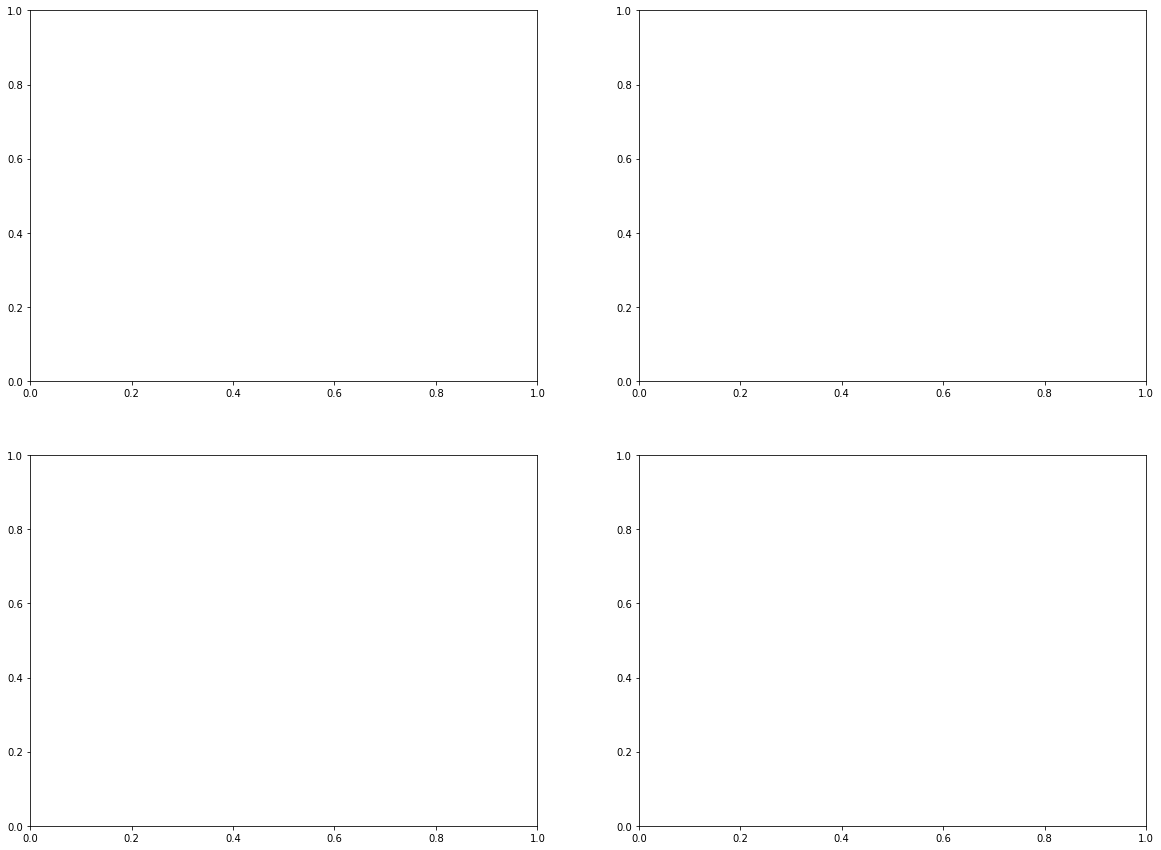

In [ ]:
fig, ax= plt.subplots(nrows=2, ncols=2, figsize=(20,15))

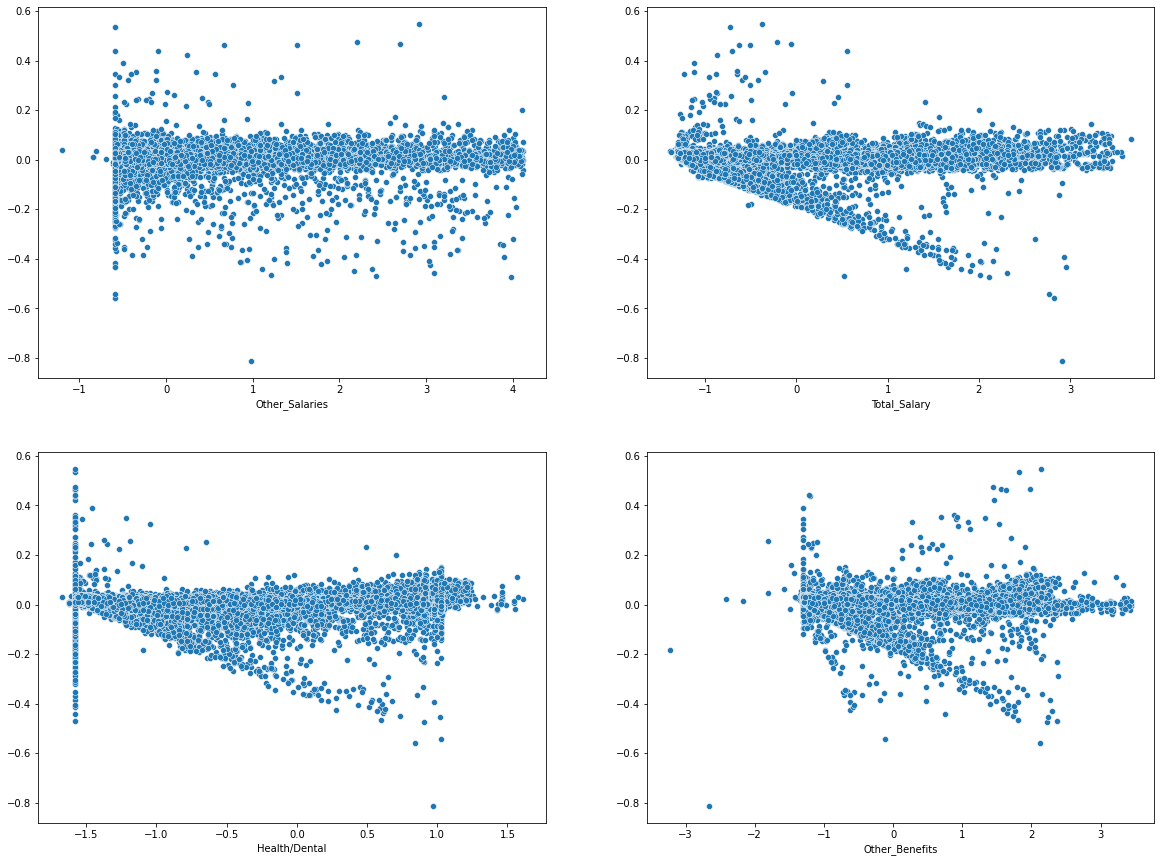

In [ ]:
# create subplots of scatter plots
# pass the number of rows in a subplot to 'nrows'
# pass the number of columns in a subplot to 'ncolumns'
# set plot size using 'figsize'


fig, ax = plt.subplots(nrows = 2, ncols= 2, figsize=(20, 15))

# use for loop to create scatter plot for residuals and each independent variable (do not consider the intercept)
# 'ax' assigns axes object to draw the plot onto


for i, subplot in zip(X_train.columns[1:5], ax.flatten()):
    sns.scatterplot(X_train[i], MLR_model_with_significant_var.resid , ax=subplot)

# display the plot
plt.show()

**Interpretation:** The above plots show no specific pattern, implies that there is a linearity present in the data.

<a id="auto"></a>
### 5.3.2 Autocorrelation

We can check the correlation between the residuals using the `Durbin-Watson` test. The value of the test statistic ranges from 0 to 4. The test statistic value near to 2, represents no autocorrelation. The value of the test statistic between 0 and 2 implies positive autocorrelation and the value between 2 and 4 implies negative autocorrelation.

Print the summary of the model with significant variables to check the autocorrelation.

In [ ]:
# print the model summary
print(MLR_model_with_significant_var.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.015e+06
Date:                Sat, 04 Mar 2023   Prob (F-statistic):               0.00
Time:                        14:30:03   Log-Likelihood:                 45593.
No. Observations:               26404   AIC:                        -9.117e+04
Df Residuals:                   26396   BIC:                        -9.111e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0128      0.001    -25.

**Interpretation:** From the above summary, we can observe that the value obtained from the `Durbin-Watson` test statistic is close to 2 (= 1.997). Thus, we conclude that there is no autocorrelation.

<a id="sked"></a>
### 5.3.3 Heteroskedasticity

If the residuals have constant variance across different values of the predicted values, then it is known as `Homoskedasticity`. The absence of homoskedasticity is known as, heteroskedasticity. One of the assumptions of linear regression is that heteroskedasticity should not be present. Let us study two different tests to check the presence of  heteroskedasticity.

Breusch-Pagan is one of the tests for detecting heteroskedasticity in the residuals.<br>
The test hypothesis for the Breusch-Pagan test is given as:
<p style='text-indent:25em'> <strong> H<sub>o</sub>:  There is homoscedasticity present in the data </strong> </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>:  There is a heteroscedasticity present in the data </strong> </p>

1. The scatter plot between the residual and the fitted (predicted) model.
2. Presence or absence of Heteroscedasticity is checked in this plot.
3. There should not be any pattern. Or to say, it should be random.

1. It is funnel shape. It means that variance that you see is not the same at each point.
2. It is unequal variance. It can be increasing or decreasing variance. Such pattern are called as unequal variance.
3. If the data is not heteroscedasticity then it exhibits homoscedasticity.
4. Why does this happen ? Look at the Age and Income. As the Age increases, the experience increases, and the salary increases. Nothing wrong about it.
5. It starts creating a Funnel Structure here.  Moment you see a funnel structure, you can anticipate which model cannot work.
6. Linear regression will not work for the data which shows funnel structure or exhibiting Heteroscedasticity.
7. Heteroscedasticity is the case of unequal variance.
8. We need to have consistent variance.
9. It also significance of outliers in the data .As we have outliers, the variance of the data keeps changing.

It is a plot between fitted value and model residuals.

**BreuschPagan Test**

In [ ]:
import statsmodels.stats.api as ssa

#model.exog: It represents all the data points or input variables.
#exog : Independent Variables.
#endog : Dependent Variables.
# This is compared between residuals vs actual values.


ssa.het_breuschpagan(MLR_model_with_significant_var.resid,MLR_model_with_significant_var.model.exog)

(1215.8006918939582,
 2.7041186860526127e-258,
 182.01423084037506,
 1.7462667234869403e-264)

1. The first 2 values are BreushPagan Test statistics and p value.
2. The second set of values are FStatistics and p value.

3. BreushPagan Test Statistics -1215.8006918939582

4. BreushPagan Test p value    2.7041186860526127e-258

5. Fstatistics value is 182.01423084037506

6. Fstatistics p value is 1.7462667234869403e-264


**Interpretation:** We observe that the p-value is less than 0.05; thus, we conclude that there is heteroskedasticity present in the data.

<a id="normality"></a>
### 5.3.4 Tests for Normality

As per the assumptions of linear regression, residuals should be normally distributed. If the target variable is normally distributed then the residuals are also normally distributed, thus we check the normality only for the target variable.

<a id="qq"></a>
#### 1. Q-Q Plot

Q-Q plot is s visualization technique to check the normality of the residuals. It plots the quantiles of observed data versus the quantiles of the standard normal distribution.

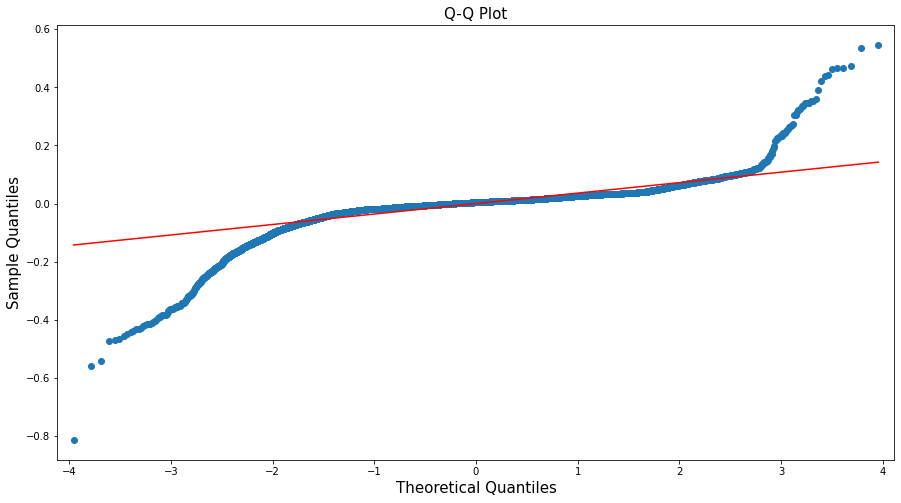

In [ ]:
# set the plot size using 'rcParams'
# once the plot size is set using 'rcParams', it sets the size of all the forthcoming plots in the file
# pass width and height in inches to 'figure.figsize'


plt.rcParams['figure.figsize'] = [15,8]

# plot the Q-Q plot
# 'r' represents the regression line

from statsmodels.graphics.gofplots import qqplot
qqplot(MLR_model_with_significant_var.resid, line = 'r')



# set plot and axes labels
# set text size using 'fontsize'
plt.title('Q-Q Plot', fontsize = 15)
plt.xlabel('Theoretical Quantiles', fontsize = 15)
plt.ylabel('Sample Quantiles', fontsize = 15)

# display the plot
plt.show()

**Interpretation:** The diagonal line (red line) is the regression line and the blue points are the cumulative distribution of the residuals. As some of the points are close to the diagonal line, we conclude that the residuals do not follow a `normal distribution`.

<a id="SWT"></a>
#### 2. Shapiro Wilk Test

The Shapiro Wilk test is used to check the normality of the residuals. The test hypothesis is given as:<br>

<p style='text-indent:25em'> <strong> H<sub>o</sub>:  Residuals are normally distributed </strong> </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>:  Residuals are not normally distributed </strong> </p>

In [ ]:
# perform Shapiro Wilk test using 'shapiro()' from scipy library
# shapiro() returns a tuple having the values of test statistics and the corresponding p-value
# 'resid' returns the residuals in the model
# pass the residuals to 'shapiro()'


from scipy.stats import shapiro
stat, p_value = shapiro(MLR_model_with_significant_var.resid)

# print the test statistic and corresponding p-value


print('Test statistic:', stat)
print('P-Value:', p_value)

Test statistic: 0.7002706527709961
P-Value: 0.0


**Interpretation:** From the above test we can see that the p-value is 0.0 (less than 0.05), thus we can say that the residuals are not normally distributed.

<a id="eval"></a>
# 6. Model Evaluation

In this section, we evaluate the model containing significant variables.

Let us print the summary of the multiple regression model.

In [ ]:
# print the model summary
print(MLR_model_with_significant_var.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.015e+06
Date:                Sat, 04 Mar 2023   Prob (F-statistic):               0.00
Time:                        14:30:04   Log-Likelihood:                 45593.
No. Observations:               26404   AIC:                        -9.117e+04
Df Residuals:                   26396   BIC:                        -9.111e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0128      0.001    -25.

<a id="R_squared"></a>
## 6.1 R-Squared

The coefficient of determination explains the percentage of variation in the dependent variable that the independent variables explain collectively.

In [ ]:
# calculate R-Squared on train dataset
# use 'rsquared' from statsmodel


r_sq_mlr = MLR_model_with_significant_var.rsquared

# print the value
r_sq_mlr

0.9981317295862211

**Interpretation:** The value of R-squared is 0.963. Thus, we conclude that the 96.3% variation in the Total_Compensation is explained by the model. We can also obtain this value from the summary of the model.

<a id="Adj_R_test"></a>
## 6.2 Adjusted R-Squared

It explains the percentage of variation by the independent variables that affect the target variable. The value of adjusted R-squared is always less than R-squared.

In [ ]:
# calculate adjusted R-Squared on train dataset
# use 'rsquared_adj' from statsmodel


adj_r_sq = MLR_model_with_significant_var.rsquared_adj

# print the value
adj_r_sq

0.998131234136422

Now, we can also calculate the adjusted R-Squared value using the formula **1 - (((1 - R-Squared) * (n - 1)) / (n - k - 1))**.

Where,<br>k: Number of beta coefficients <br>
n: Total number of observations

## Overall F Test and p Value of the Model

F-test is used to checking whether the overall regression model is statistically significant or not. The F-statistic is given as:



The test hypothesis for F-test is given as:
<p style='text-indent:25em'> <strong> H<sub>o</sub>: All β's are equal to zero </strong> (i.e. regression model is not significant) </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>: At least one β is not equal to zero </strong> (i.e. regression model is significant) </p>

In [ ]:
# From the Stats above
'''
   F-statistic:                 2.015e+06
   Prob (F-statistic):               0.00

'''

'\n   F-statistic:                 2.015e+06\n   Prob (F-statistic):               0.00\n\n'

**Interpretation:** As, the p-value is less than 0.05, we reject the null hypothesis; i.e. the model is significant.

<a id="ml_perf"></a>
# 7. Model Performance

#### Let us do some predictions using the train and test dataset.

In [ ]:
# For training set:
# train_pred: prediction made by the model on the training dataset 'X_train'
# y_train: actual values of the target variable for the train dataset

# For testing set:
# test_pred: prediction made by the model on the test dataset 'X_test'
# y_test: actual values of the target variable for the test dataset

# predict the output of the target variable from the train data
# train_pred can also be obtained from "MLR_model_with_significant_var.fittedvalues"



In [ ]:
train_pred = MLR_model_with_significant_var.predict(X_train)

# predict the output of the target variable from the test data
test_pred = MLR_model_with_significant_var.predict(X_test)

<a id="mse"></a>
## 7.1 Mean Squared Error (MSE)

It is defined as the average squared difference between the actual and predicted values.

In [ ]:
# calculate the MSE using the "mean_squared_error" function

# calculate the MSE for the train data
# round the value upto 4 digits using 'round()'



mse_train = round(mean_squared_error(y_train, train_pred),4)

# print the MSE for the training set
print("Mean Squared Error (MSE) on training set: ", mse_train)

# calculate the MSE for the test data
# round the value upto 4 digits using 'round()'


mse_test = round(mean_squared_error(y_test, test_pred),4)

# print the MSE for the test set
print("Mean Squared Error (MSE) on test set: ", mse_test)

Mean Squared Error (MSE) on training set:  0.0019
Mean Squared Error (MSE) on test set:  0.0016


<a id="rmse"></a>
## 7.2 Root Mean Squared Error (RMSE)

It is defined as the square root of MSE. Lower the value of RMSE, better is the fit of the regression line.

In [ ]:
# calculate the MSE using the "mean_squared_error" function

# MSE for the train data
mse_train = mean_squared_error(y_train, train_pred)

# take the square root of the MSE to calculate the RMSE
# round the value upto 4 digits using 'round()'

rmse_train = round(np.sqrt(mse_train), 4)

# print the RMSE for the train set
print("Root Mean Squared Error (RMSE) on training set: ", rmse_train)

# MSE for the test data
mse_test = mean_squared_error(y_test, test_pred)

# take the square root of the MSE to calculate the RMSE
# round the value upto 4 digits using 'round()'

rmse_test = round(np.sqrt(mse_test), 4)

# print the RMSE for the test set
print("Root Mean Squared Error (RMSE) on test set: ", rmse_test)

Root Mean Squared Error (RMSE) on training set:  0.043
Root Mean Squared Error (RMSE) on test set:  0.0404


<a id="mae"></a>
## 7.3 Mean Absolute Error (MAE)

It is defined as the average of the absolute difference between the actual and predicted values.

In [ ]:
# calculate the MAE using the "mean_absolute_error" function

# calculate the MAE for the train data
# round the value upto 4 digits using 'round()'

mae_train = round(mean_absolute_error(y_train, train_pred),4)

# print the MAE for the training set
print("Mean Absolute Error (MAE) on training set: ", mae_train)

# calculate the MAE for the test data
# round the value upto 4 digits using 'round()'
mae_test = round(mean_absolute_error(y_test, test_pred),4)

# print the MAE for the test set
print("Mean Absolute Error (MAE) on test set: ", mae_test)

Mean Absolute Error (MAE) on training set:  0.0236
Mean Absolute Error (MAE) on test set:  0.0232


<a id="mape"></a>
## 7.4 Mean Absolute Percentage Error (MAPE)

It is used to measure the accuracy of the model as a percentage. We define a function to calculate MAPE for training and test dataset.

In [ ]:
# define a function to calculate MAPE
# pass the actual and predicted values as input to the function
# return the calculated MAPE


def mape(actual, predicted):
    return (np.mean(np.abs((actual - predicted) / actual)) * 100)

In [ ]:
# calculate the mape using the "mape()" function created above

# calculate the MAPE for the train data
# round the value upto 4 digits using 'round()'


mape_train = round(mape(y_train, train_pred),4)

# print the MAPE for the training set
print("Mean Absolute Percentage Error (MAPE) on training set: ", mape_train)

# calculate the MAPE for the test data
# round the value upto 4 digits using 'round()'


mape_test = round(mape(y_test, test_pred),4)

# print the MAPE for the test set
print("Mean Absolute Percentage Error (MAPE) on test set: ", mape_test)

Mean Absolute Percentage Error (MAPE) on training set:  10.822
Mean Absolute Percentage Error (MAPE) on test set:  10.8686


<a id="compare"></a>
# 8. Compare Model Performances

Let us compare the model performance metrics (MSE, RMSE, MAE, MAPE) for `MLR_full_model`, `MLR_model_with_significant_var` and `MLR_interaction_model` to find the best model.

In [ ]:
# create the table for all the model performance metrics
# metrics considered for model comparision are MSE, RMSE, MAE and MAPE
# create a list of column names



cols = ['Model_Name', 'R-squared', 'Adj. R-squared', 'MSE', 'RMSE', 'MAE', 'MAPE']

# creating a empty dataframe of the colums
result_table = pd.DataFrame(columns = cols)

Now, calculate performance measure for `MLR_full_model`

In [ ]:
# calculate R-squared, Adjusted R-squared, MSE, RMSE, MAE and MAPE for full model
# use 'rsquared' to calculate R-squared value
# use 'rsquared_adj' to calculate Adjusted R-squared value
# use 'mean_squared_error' to calculate MSE
# use 'rmse' to calculate RMSE
# use 'mean_absolute_error' to calculate MAE
# use the defined function 'mape' to calculate MAPE

In [ ]:

MLR_model_signi_var_metrics = pd.Series(

                    {'Model_Name': "MLR Model with Significant Variables",
                     'R-squared': MLR_model_with_significant_var.rsquared,
                     'Adj. R-squared': MLR_model_with_significant_var.rsquared_adj,
                     'MSE': mean_squared_error(y_test, y_pred),
                     'RMSE': rmse(y_test, y_pred),
                     'MAE': mean_absolute_error(y_test, y_pred),
                     'MAPE': mape(y_test, y_pred)
                   })

# append the values to the result table
result_table = result_table.append(MLR_model_signi_var_metrics, ignore_index = True)

# print the result table
result_table

,Model_Name,R-squared,Adj. R-squared,MSE,RMSE,MAE,MAPE
0,MLR Model with Significant Variables,0.998132,0.998131,0.001633,0.040410,0.023232,10.868629


Now, calculate the performance measures for `MLR_model_with_interaction`

**Interpretation:** The R-Squared and the Adj. R-Squared for the full model (=1) indicates that the model perfectly fits the data which is not practical and also the model is likely to overfit. Thus, MLR Full Model cannot be considered as the best model.<br>

Overfitting occurs when a model learns the detail and noise in the training data to the extent that it adversely impacts the model's performance on the new data. We will learn about overfitting in the upcoming portion.<br>

On the other hand, R-Squared and the Adj. R-Squared for the MLR Model with Interaction is more than the MLR Model with Significant Variables. Also, the RMSE value for the MLR Model with Interaction is less as compared to that of MLR Model with Significant Variables.<br>
Thus, we can say that the MLR Model with Interaction is the best model.

